In [35]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as LogNorm
import matplotlib.ticker as ticker
import math
import csv 
import sys

#python makeRatios.py outfile file_1 title_1 file_2 title_2 ...
#outFileName = sys.argv[1]
inFile_2 = uproot.open("../histograms/analysis_note/ratios_2d_k.root")
inFile_1 = uproot.open("../histograms/analysis_note/ratios_2d_rho_pim.root")

colorList = ['red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray']



In [36]:
def ff(z):
	return (1-z)/(z+1)

In [37]:
def edit_ax(ax):
    ax.set_ylim( [.5, 1.5] )   
    ax.set_xlim( [.3, .8] )
		
    z = np.linspace( .3, 1, 500 )
    ax.axhline( y=1, xmin=0, xmax=1 , color = 'black', linestyle = '--')
	
    ax.set_xlabel(r'$z$')
    ax.set_ylabel(r'$r(z)$')


In [38]:
def make_plots(inFile1, inFile2, ax, q, x, label, colorIdx):
    hist_1 = inFile1[f'hRatio_{q+1}_{x+1}']
    hist_2 = inFile2[f'hRatio_{q+1}_{x+1}']
    
    values_1 =np.array( hist_1.values() )
    values_1[values_1 <= 0] = np.nan
    if( np.isnan(values_1).all() ):
        return
    errors_1 = np.array(hist_1.errors())

    values_2 =np.array( hist_2.values() )
    values_2[values_2 <= 0] = np.nan
    if( np.isnan(values_2).all() ):
        return
    errors_2 = np.array(hist_2.errors())

    xEdges = hist_1.axis().edges()
    binCenters = np.asarray((xEdges[:-1]+xEdges[1:])/2 + ( -.01 + .002*colorIdx))


    #label_x = r'%.2f $< x_B <$ %.2f'%( .01 + .04*x, .1 + .04*(x+1))

    ratio = values_2/values_1
    ratio_err =  ratio*np.sqrt( (errors_1/values_2)**2 + (errors_1/values_2)**2)
    ratio_err[ratio_err<=0] = np.nan

    ax.errorbar( binCenters, ratio, ratio_err, marker='o',
                        color = colorList[colorIdx], linestyle = '',capsize = 2, lw = 1, capthick = 1, label=label)

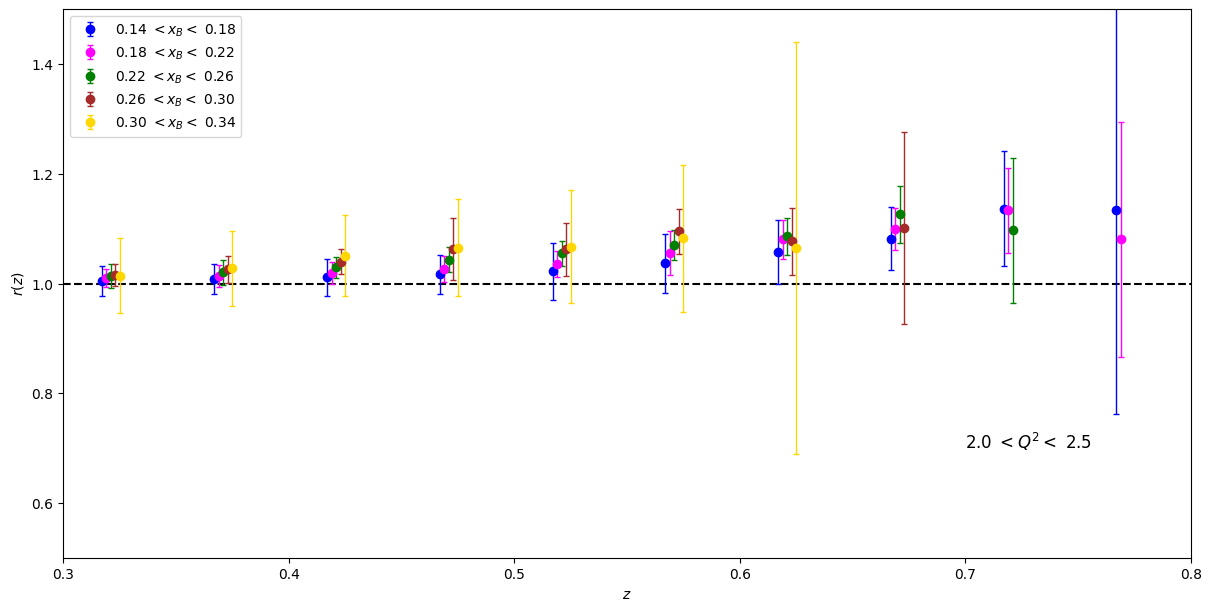

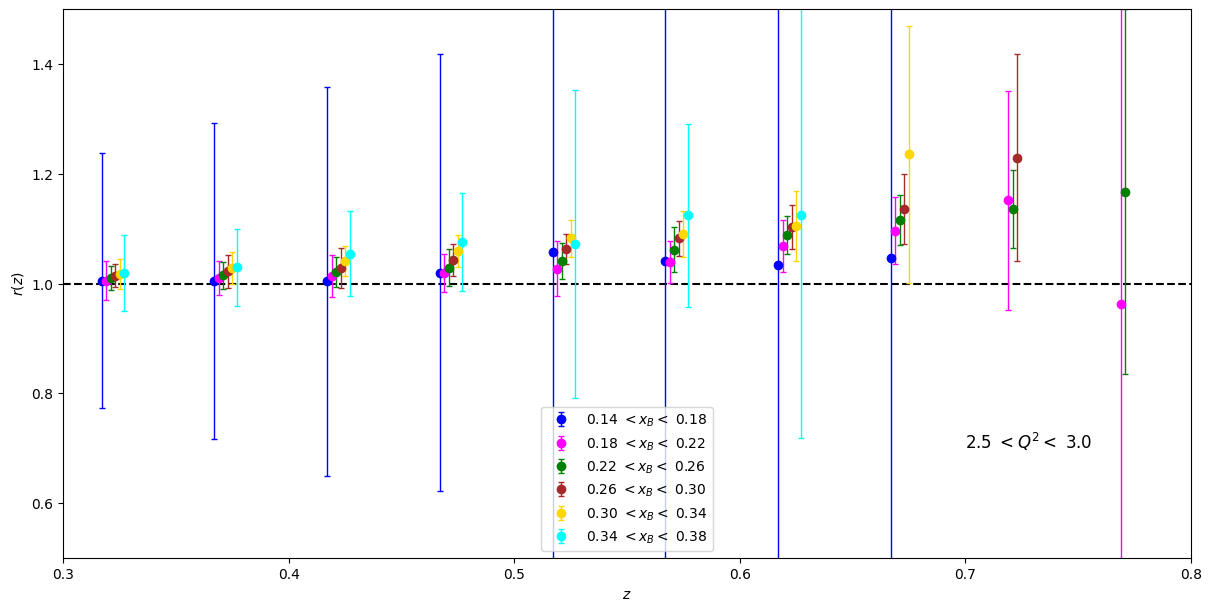

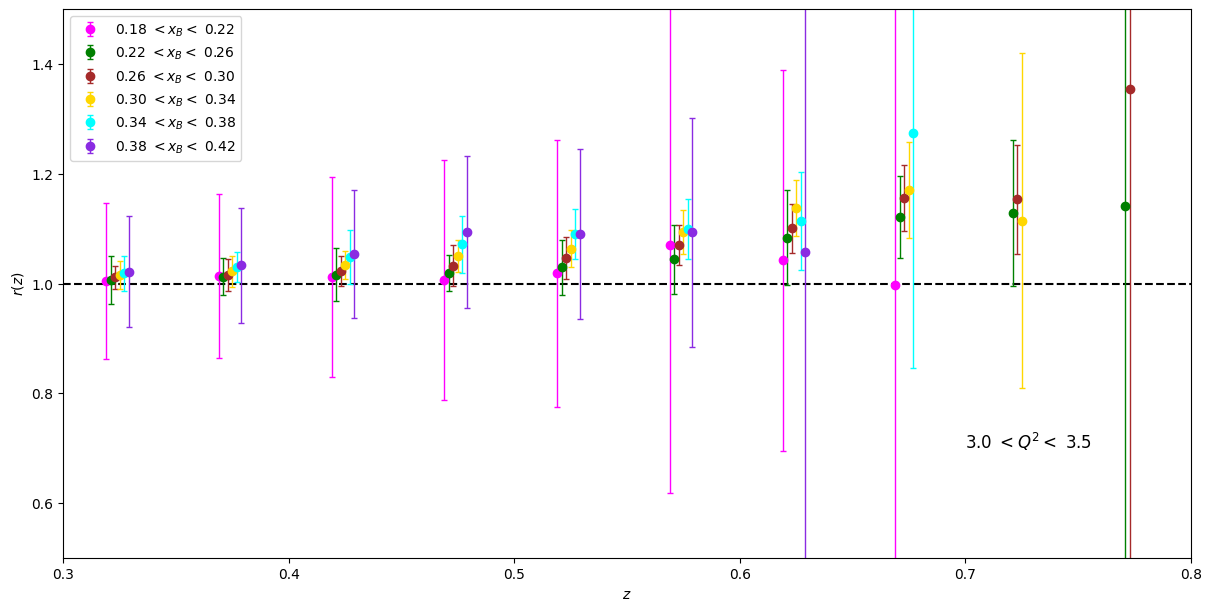

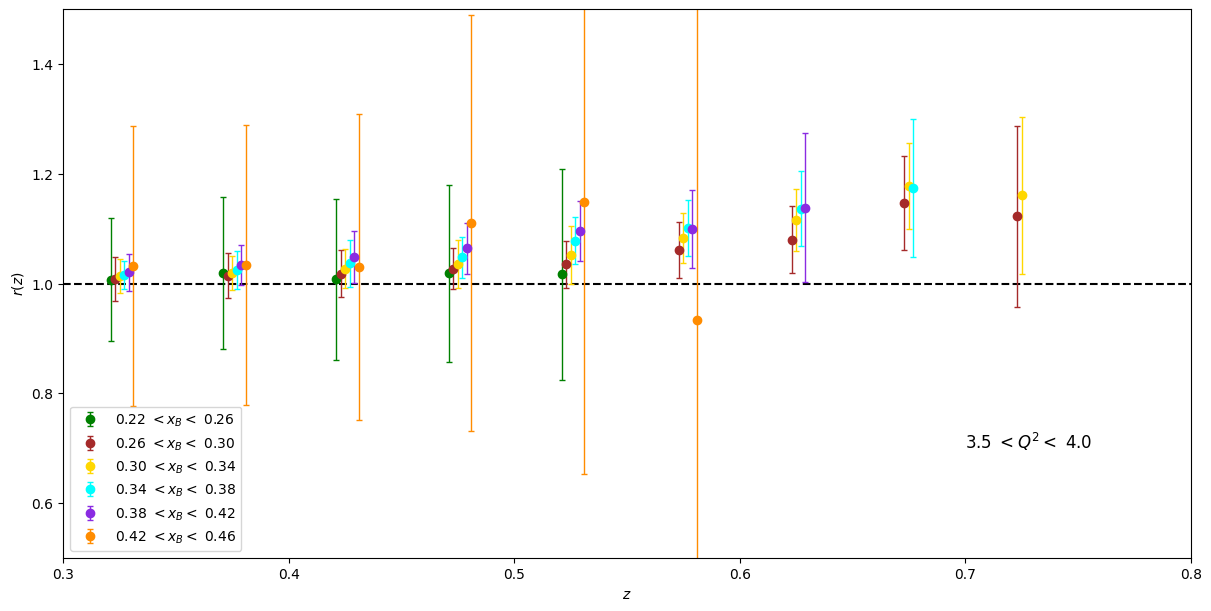

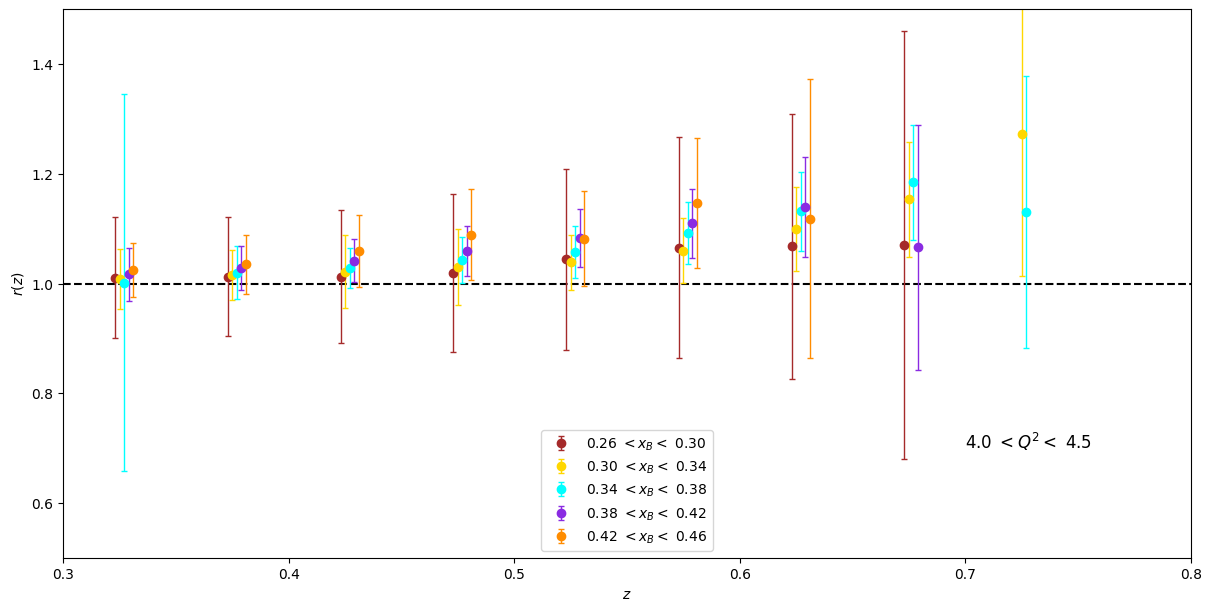

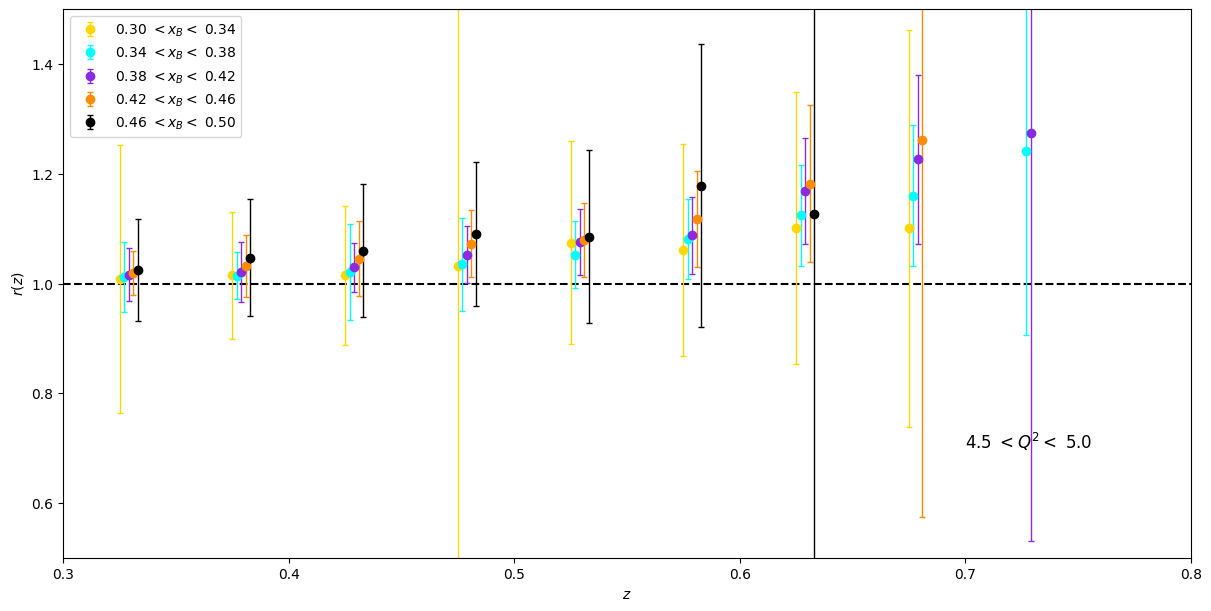

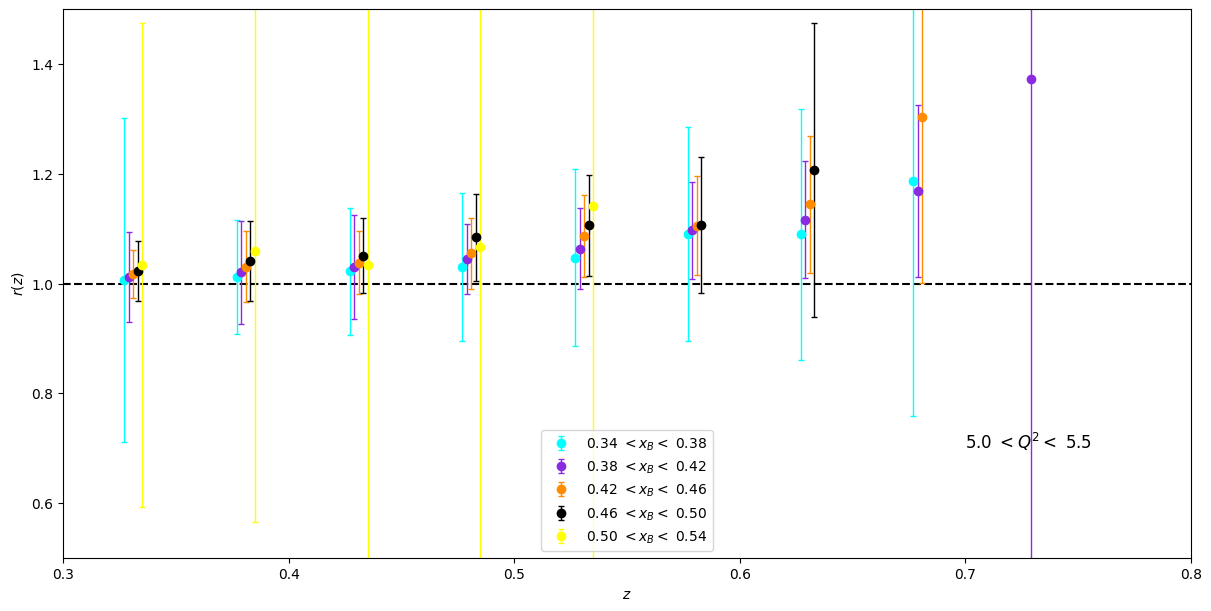

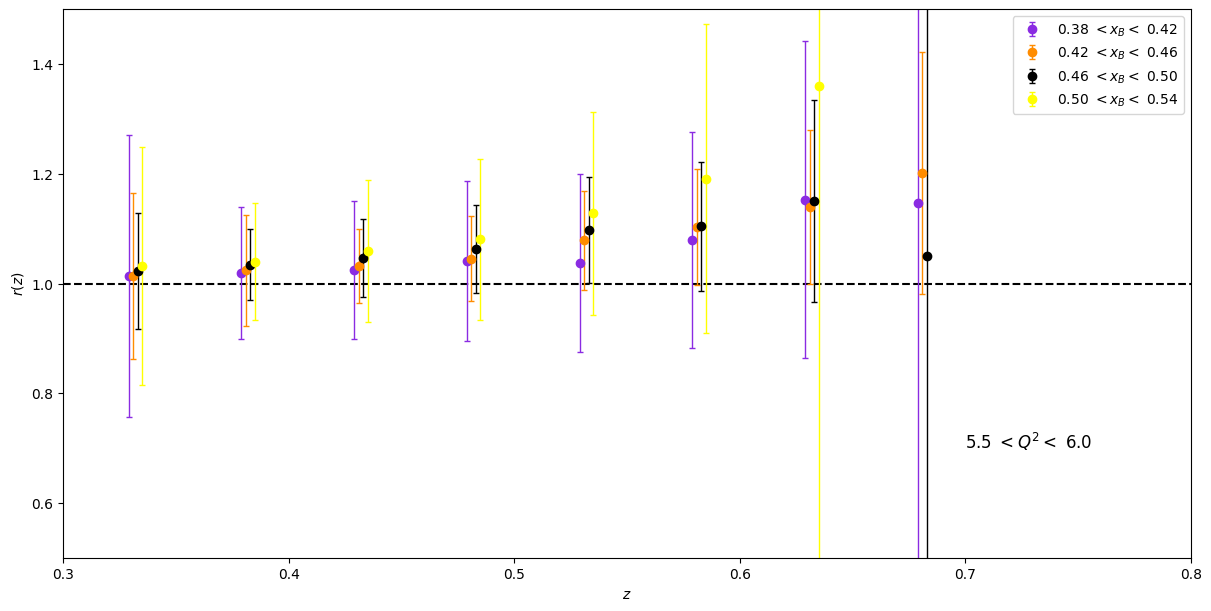

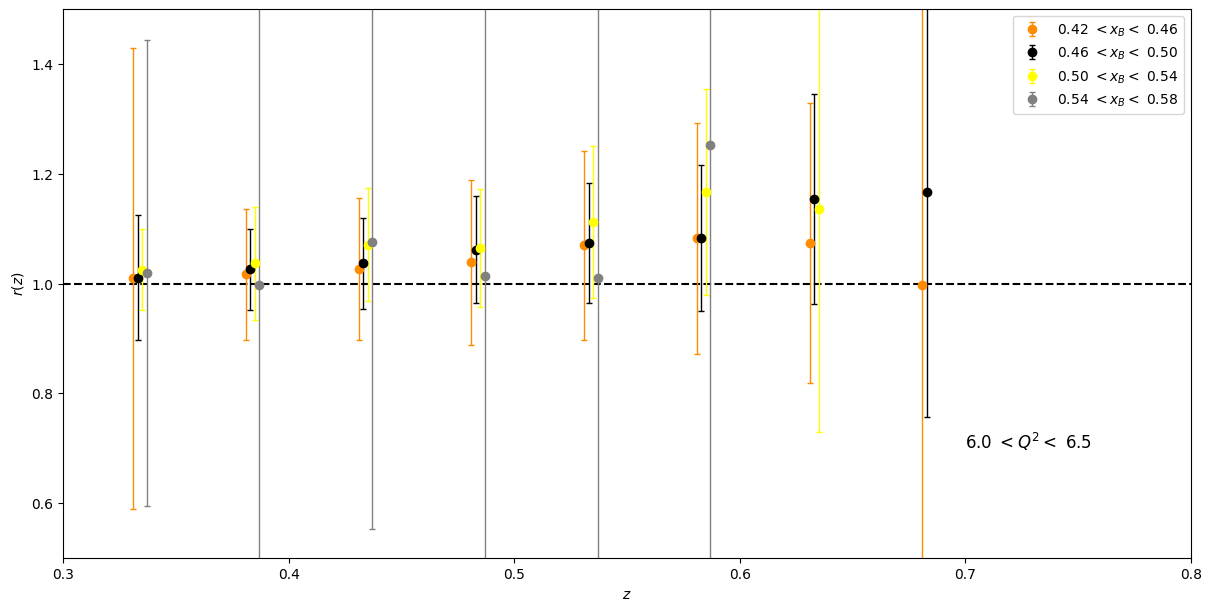

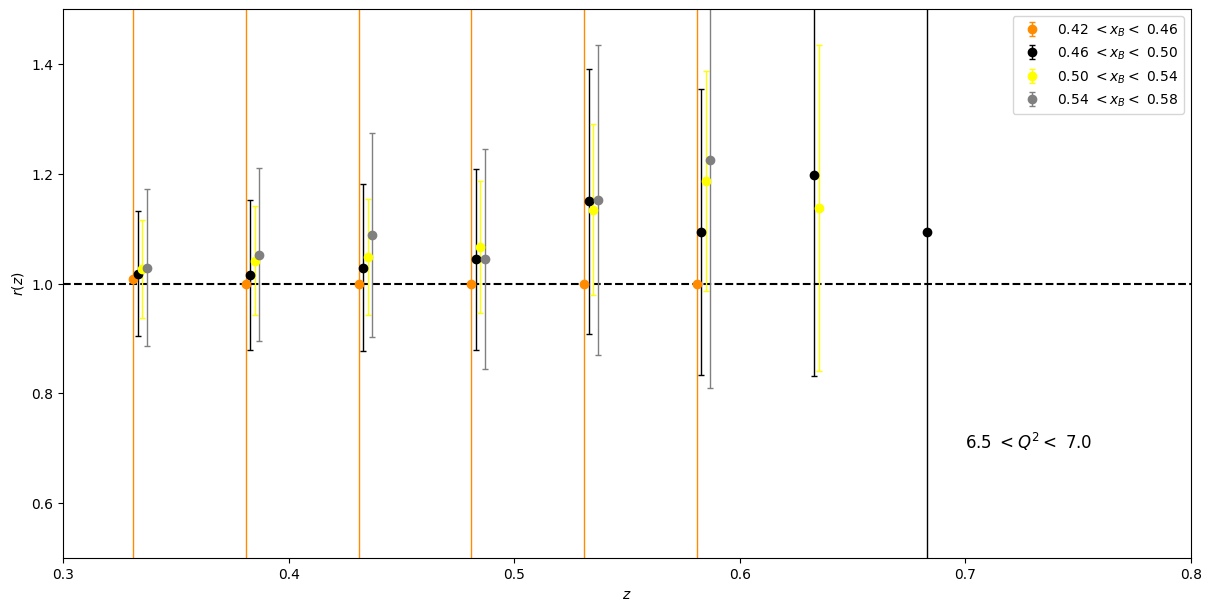

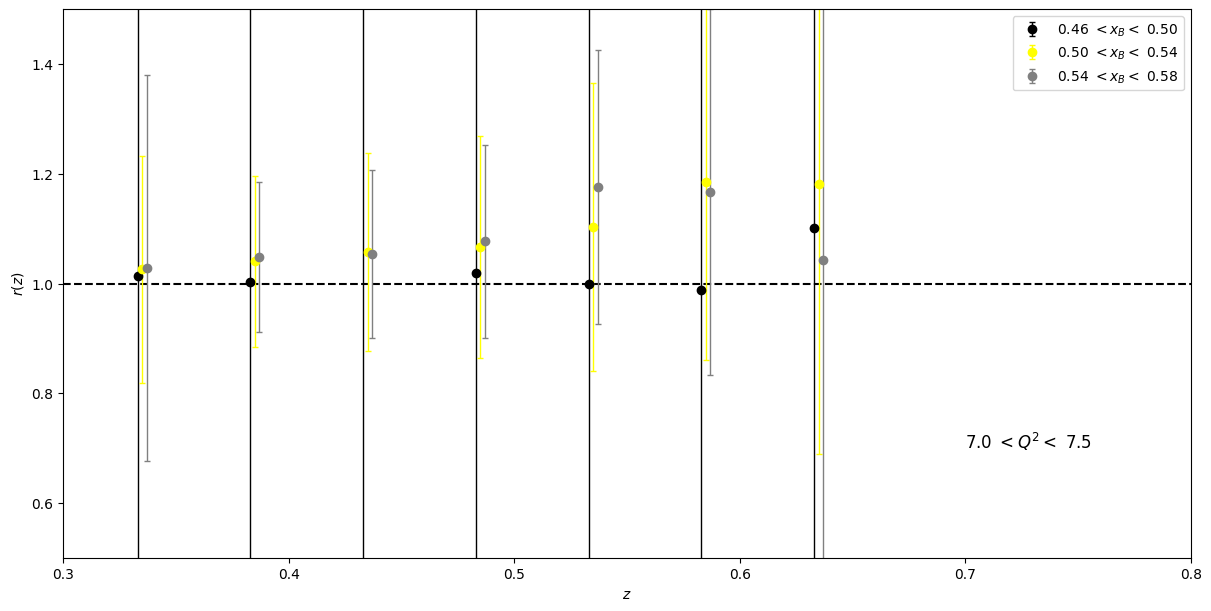

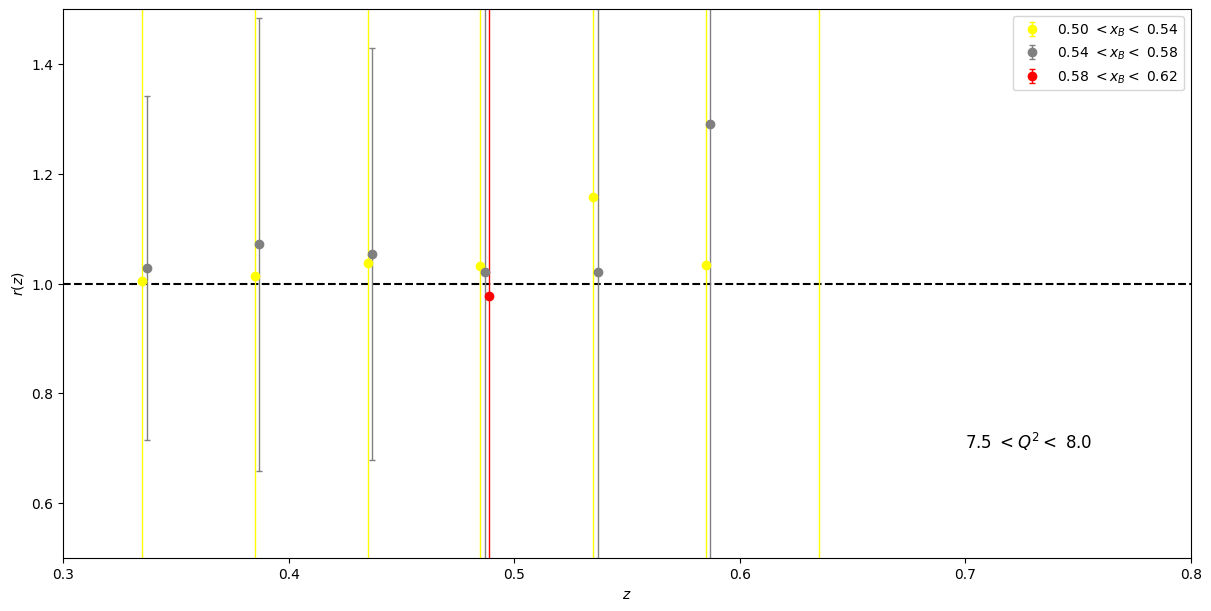

In [40]:
for q in range(12):
	
	fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
	edit_ax(ax)

	ax.text(.7, .7, r'%.1f $< Q^2 <$ %.1f'%(2 + .5*(q), 2+.5*(q+1)), fontsize=12)
	
	for x in range(14):
	
		label_x = r'%.2f $< x_B <$ %.2f'%( .1 + .04*x, .1 + .04*(x+1))
		make_plots(inFile_1, inFile_2, ax,q, x, label_x, x)


		

	ax.legend()
		#plt.text(.95, .5, r'%.2f $< x_B <$ %.2f'%( .1 + .04*x, .1 + .04*(x+1) ), fontsize=12)
		#plt.title( r'%.1f $< Q^2 <$ %.1f [GeV$^2$]'%( 2 + 0.5*q, 2 + 0.5*(q+1) ), fontsize=16)
	#fig.savefig('{0}/ratio_{1}.pdf'.format(outFileName, q+1))
		
	#plt.close()

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_65688/2292069236.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


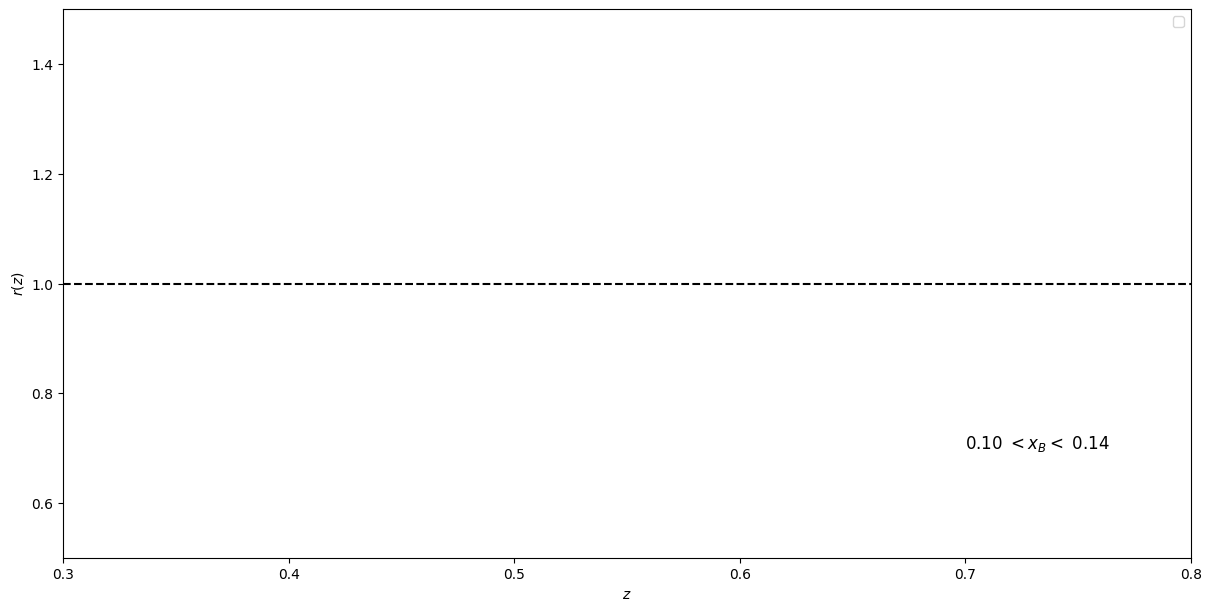

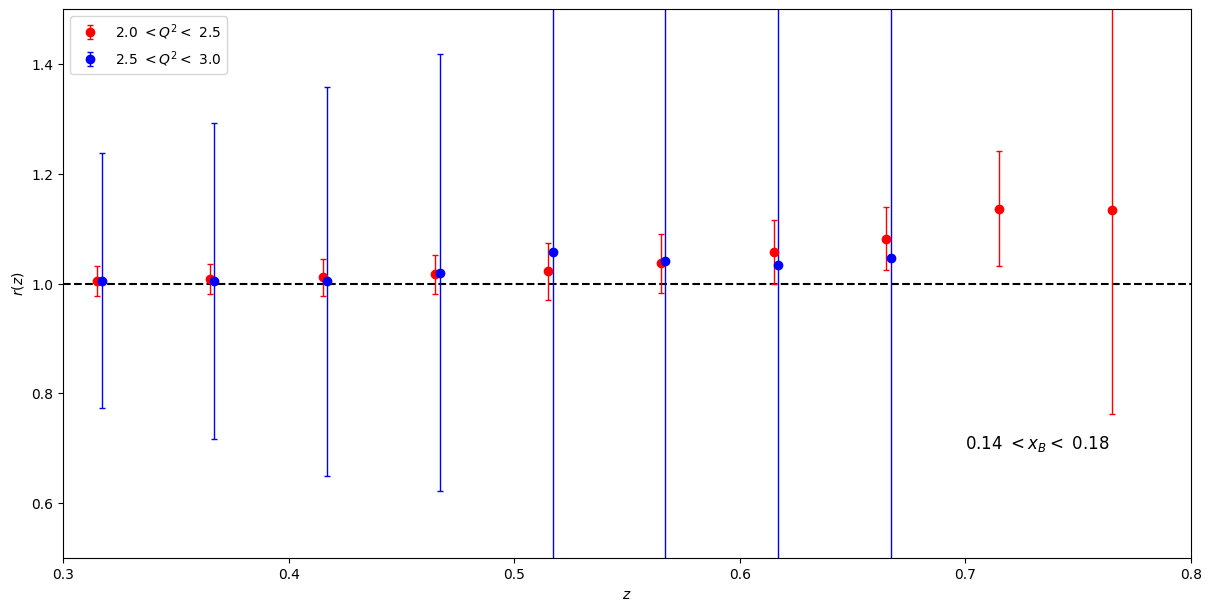

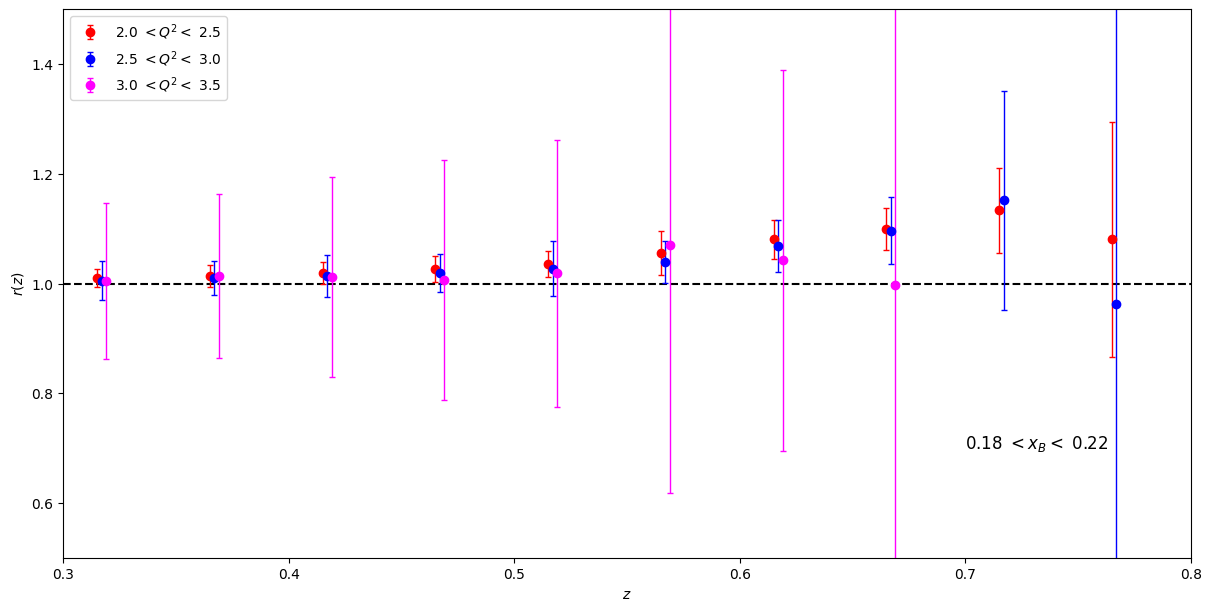

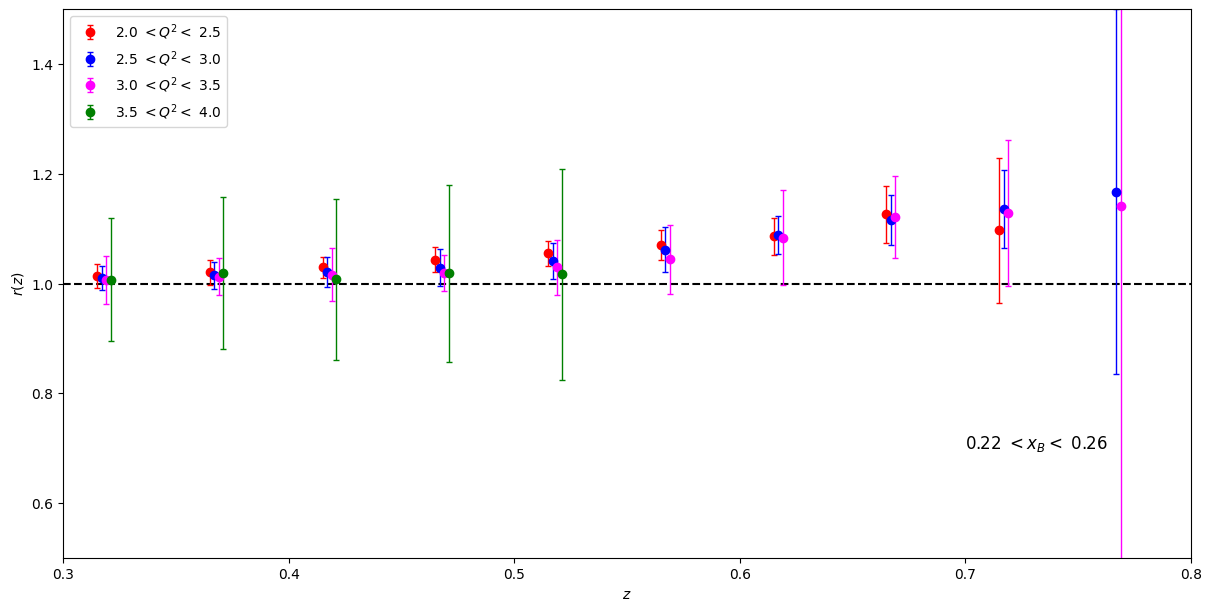

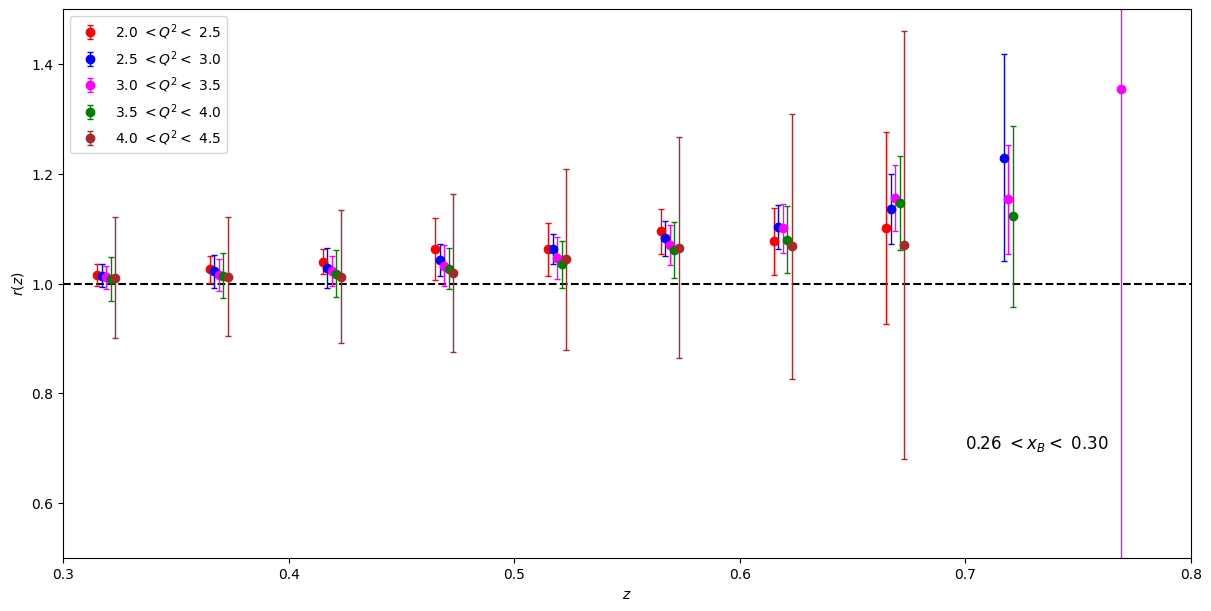

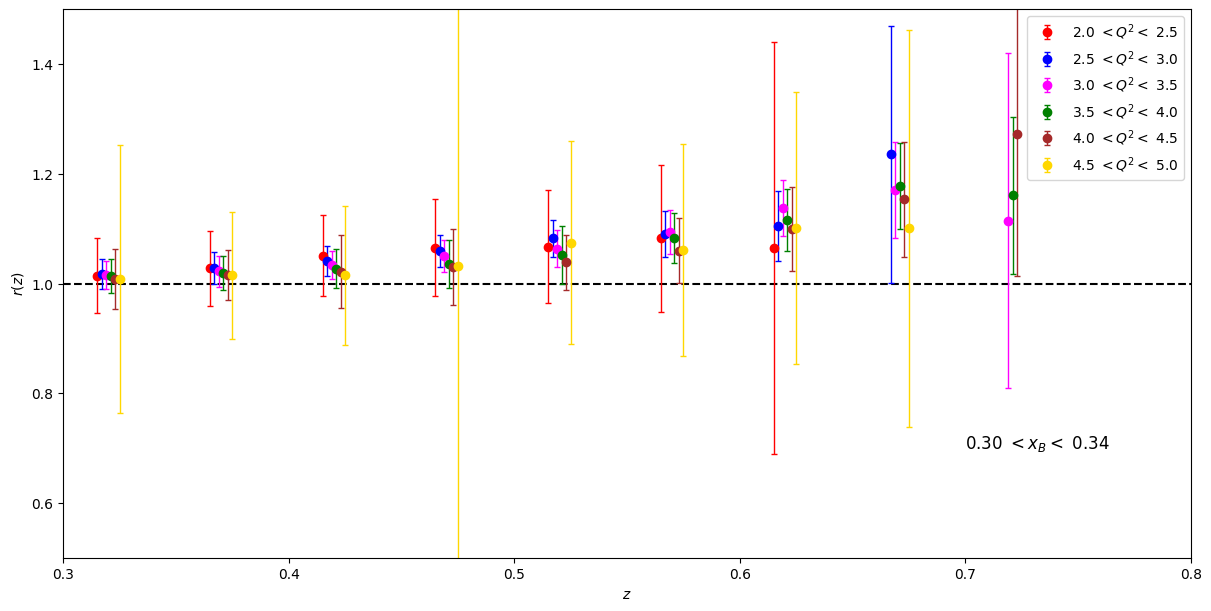

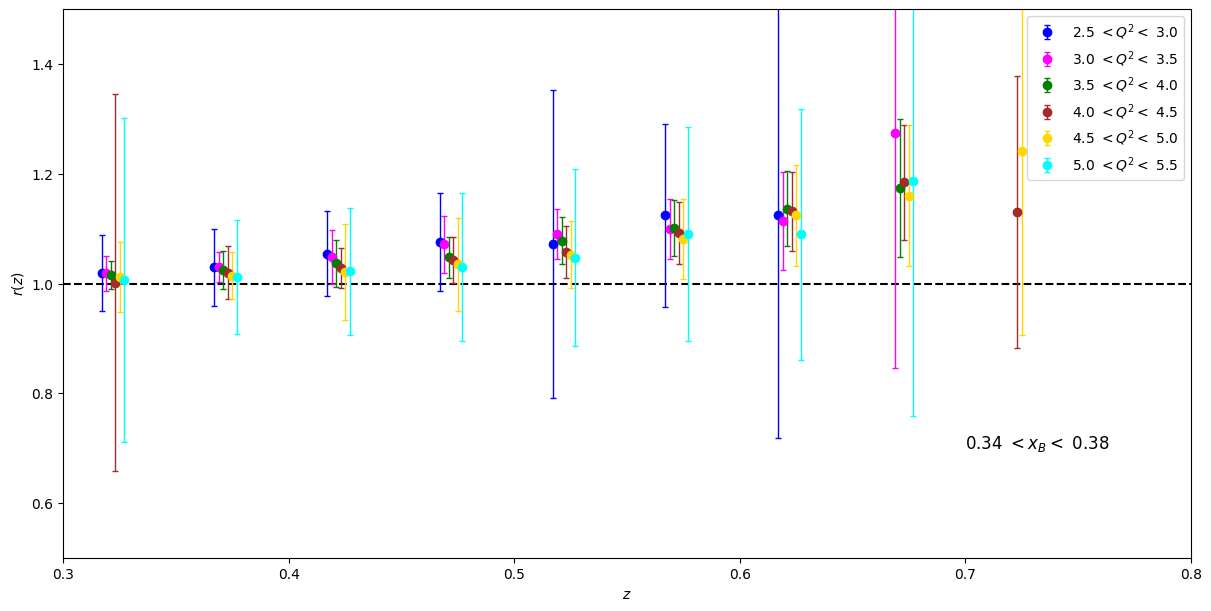

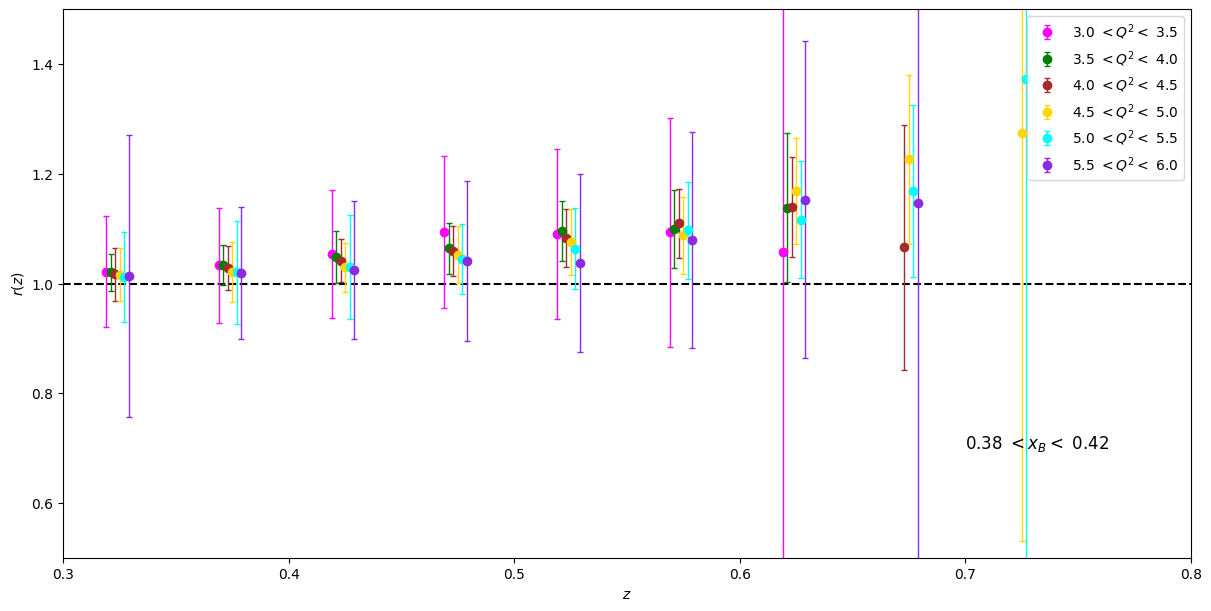

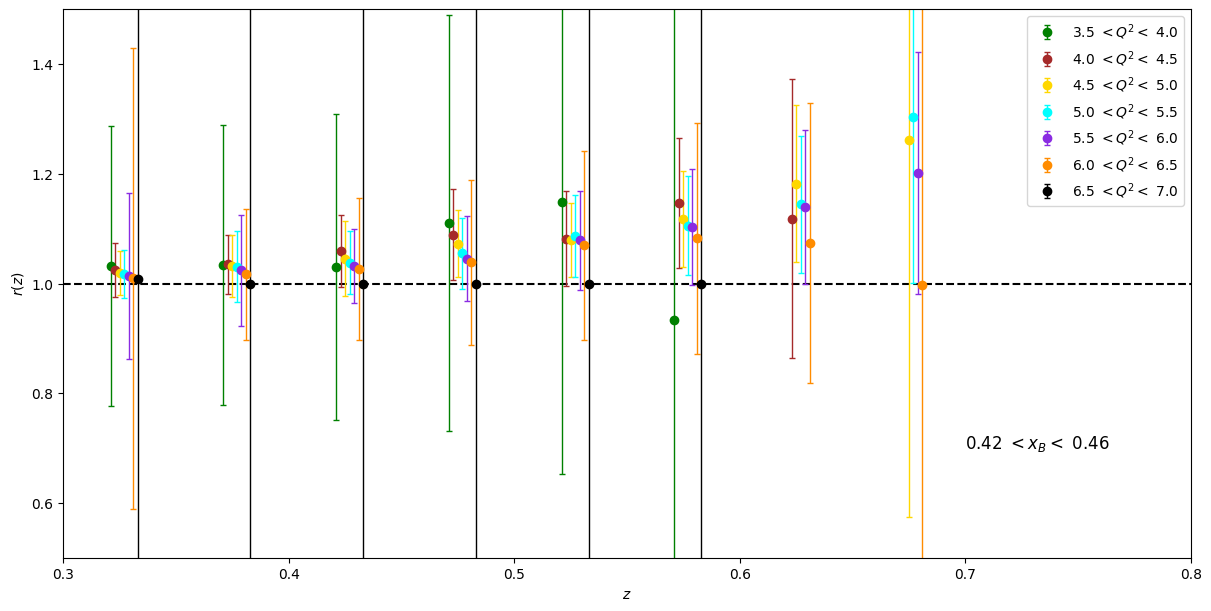

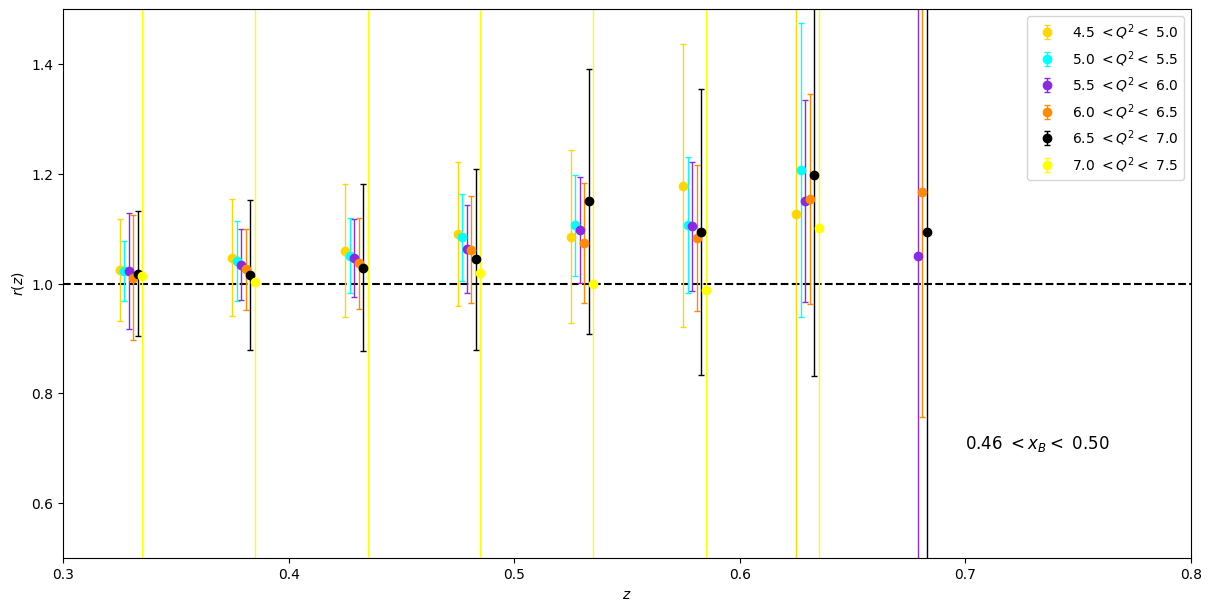

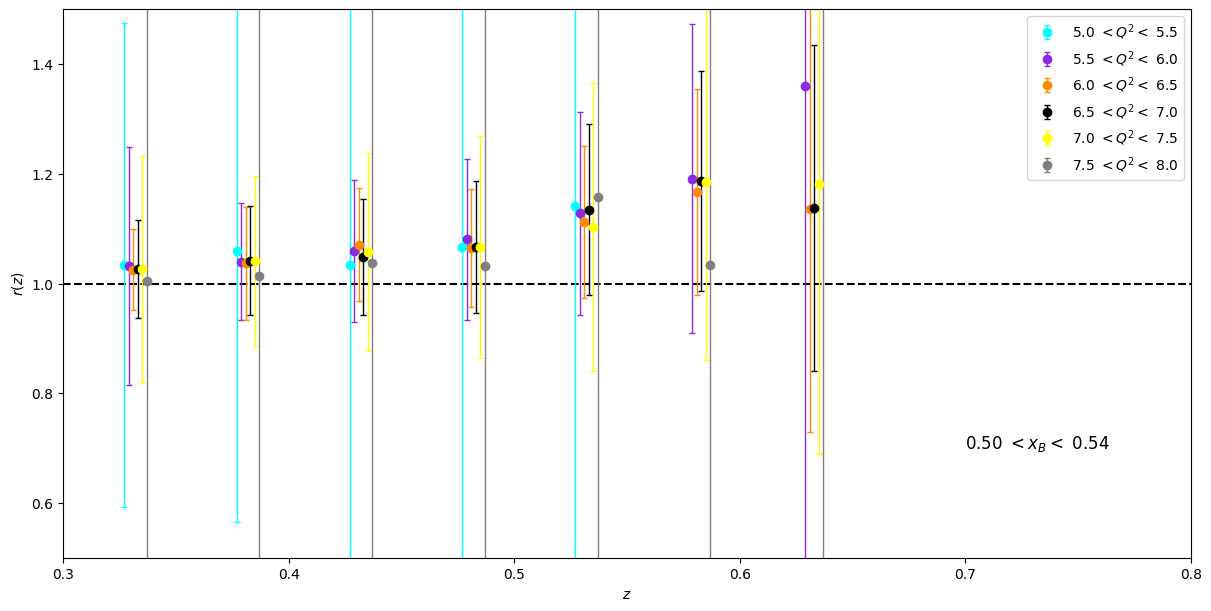

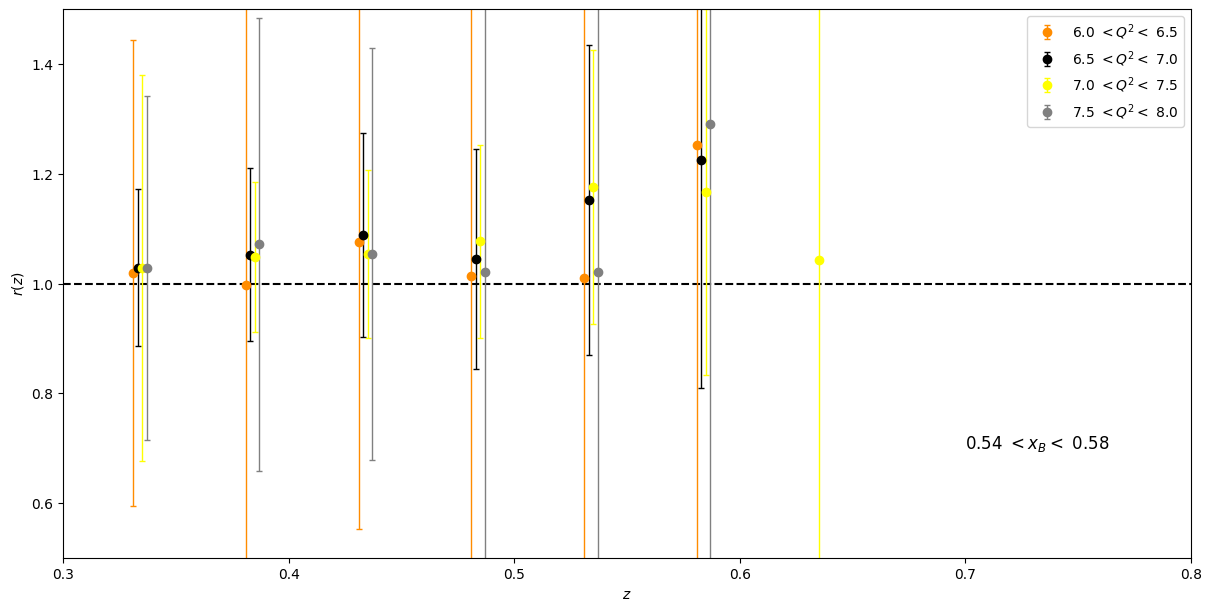

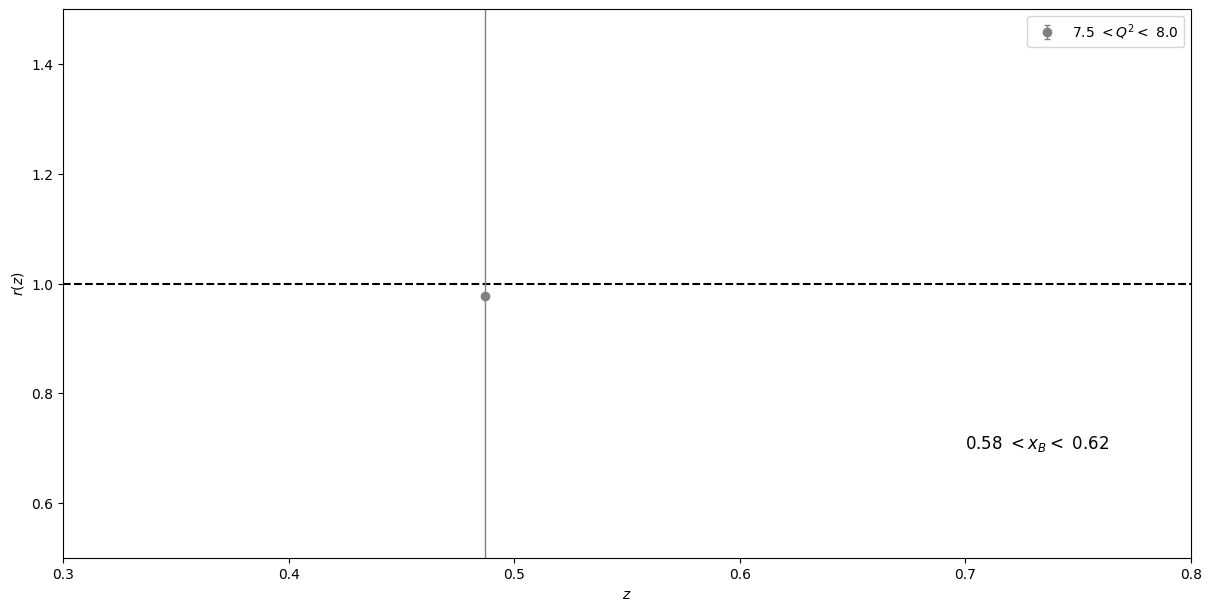

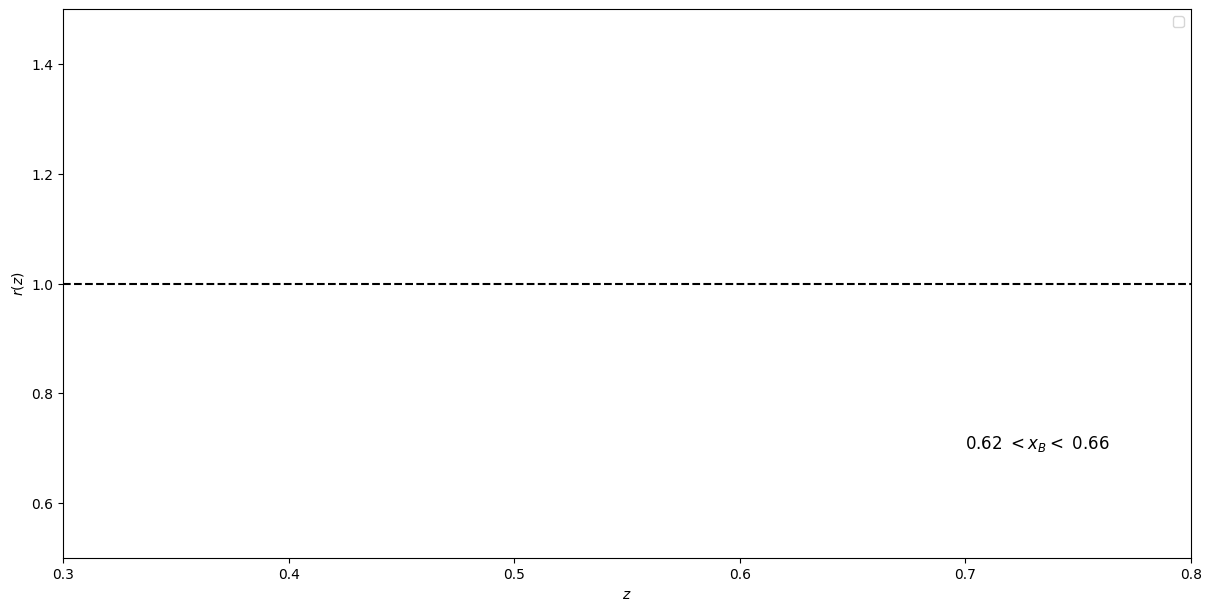

In [41]:
for x in range(14):
	
	fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
	edit_ax(ax)

	ax.text(.7, .7, r'%.2f $< x_B <$ %.2f'%( .1 + .04*x, .1 + .04*(x+1)), fontsize=12)
	for q in range(12):
	
		label_x = r'%.1f $< Q^2 <$ %.1f'%(2 + .5*(q), 2+.5*(q+1))
		make_plots(inFile_1, inFile_2, ax,q, x, label_x, q)


		

	ax.legend()